# TensorBoard Log Analysis

## 1. Setup & Data Extraction

We use `tensorboard.backend.event_processing.event_accumulator` to parse the log file natively. We will extract all available scalar tags dynamically and parse the event stream into a tabular Pandas `DataFrame`.


In [1]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Ganti dengan path ke file tfevents Anda (atau foldernya)
log_path = (
    "runs/yolo26-aksara_20260420-170211/events.out.tfevents.1776679331.G14.227926.0"
)

# Inisialisasi dan muat data
event_acc = EventAccumulator(log_path)
event_acc.Reload()

# Menampilkan daftar metrik (tags) apa saja yang direkam dalam file tersebut
print("Metrik yang tersedia:")
print(event_acc.Tags())

W0000 00:00:1776680029.311402  239006 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776680029.311470  239006 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776680029.311477  239006 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776680029.311482  239006 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
2026-04-20 17:13:49.321551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow wi

Metrik yang tersedia:
{'images': ['Weights/Images/model.0.conv', 'Weights/Images/model.1.conv', 'Weights/Images/model.2.cv1.conv', 'Weights/Images/model.2.cv2.conv', 'Weights/Images/model.2.m.0.cv1.conv', 'Weights/Images/model.2.m.0.cv2.conv', 'Weights/Images/model.3.conv', 'Weights/Images/model.4.cv1.conv', 'Weights/Images/model.4.cv2.conv', 'Weights/Images/model.4.m.0.cv1.conv', 'Weights/Images/model.4.m.0.cv2.conv', 'Weights/Images/model.5.conv', 'Weights/Images/model.6.cv1.conv', 'Weights/Images/model.6.cv2.conv', 'Weights/Images/model.6.m.0.cv1.conv', 'Weights/Images/model.6.m.0.cv2.conv', 'Weights/Images/model.6.m.0.cv3.conv', 'Weights/Images/model.6.m.0.m.0.cv1.conv', 'Weights/Images/model.6.m.0.m.0.cv2.conv', 'Weights/Images/model.6.m.0.m.1.cv1.conv', 'Weights/Images/model.6.m.0.m.1.cv2.conv', 'Weights/Images/model.7.conv', 'Weights/Images/model.8.cv1.conv', 'Weights/Images/model.8.cv2.conv', 'Weights/Images/model.8.m.0.cv1.conv', 'Weights/Images/model.8.m.0.cv2.conv', 'Weights

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Target TensorBoard event file
log_path = (
    "runs/yolo26-aksara_20260420-170211/events.out.tfevents.1776679331.G14.227926.0"
)

print(f"Loading TensorBoard logs from:\n{log_path} ...\n")
event_acc = EventAccumulator(log_path)
event_acc.Reload()

# Extract all available scalar tags
tags = event_acc.Tags()["scalars"]
print(f"Discovered {len(tags)} Scalar Tags: {tags}\n")

# Convert extracted scalar data into a clean pandas DataFrame
data_buffer = []
for tag in tags:
    events = event_acc.Scalars(tag)
    for event in events:
        data_buffer.append(
            {
                "Metric": tag,
                "Step": event.step,
                "Value": event.value,
                "Wall_Time": event.wall_time,
            }
        )

df = pd.DataFrame(data_buffer)

# Standardize time for better readability
df["Time"] = pd.to_datetime(df["Wall_Time"], unit="s")
display(df.head())

Loading TensorBoard logs from:
runs/yolo26-aksara_20260420-170211/events.out.tfevents.1776679331.G14.227926.0 ...

Discovered 5 Scalar Tags: ['Loss/Train', 'Accuracy/Train', 'Loss/Validation', 'Accuracy/Validation', 'LearningRate']



,Metric,Step,Value,Wall_Time,Time
0,Loss/Train,0,0.670838,1.776679e+09,2026-04-20 10:02:27.581213951
1,Loss/Train,1,0.068377,1.776679e+09,2026-04-20 10:02:32.038169861
2,Loss/Train,2,0.032530,1.776679e+09,2026-04-20 10:02:36.618141890
3,Loss/Train,3,0.026259,1.776679e+09,2026-04-20 10:02:41.316130161
4,Loss/Train,4,0.012808,1.776679e+09,2026-04-20 10:02:46.052381992


## 2. Exploratory Data Analysis (Visualizations)

With our data cleanly stored in a DataFrame, we can use `seaborn` and `matplotlib` to visualize the performance metrics over time. The script below logically separates 'Loss' metrics from purely evaluative 'Metrics' (like mAP or Accuracy), plotting them on distinct subplots with grids and legends.


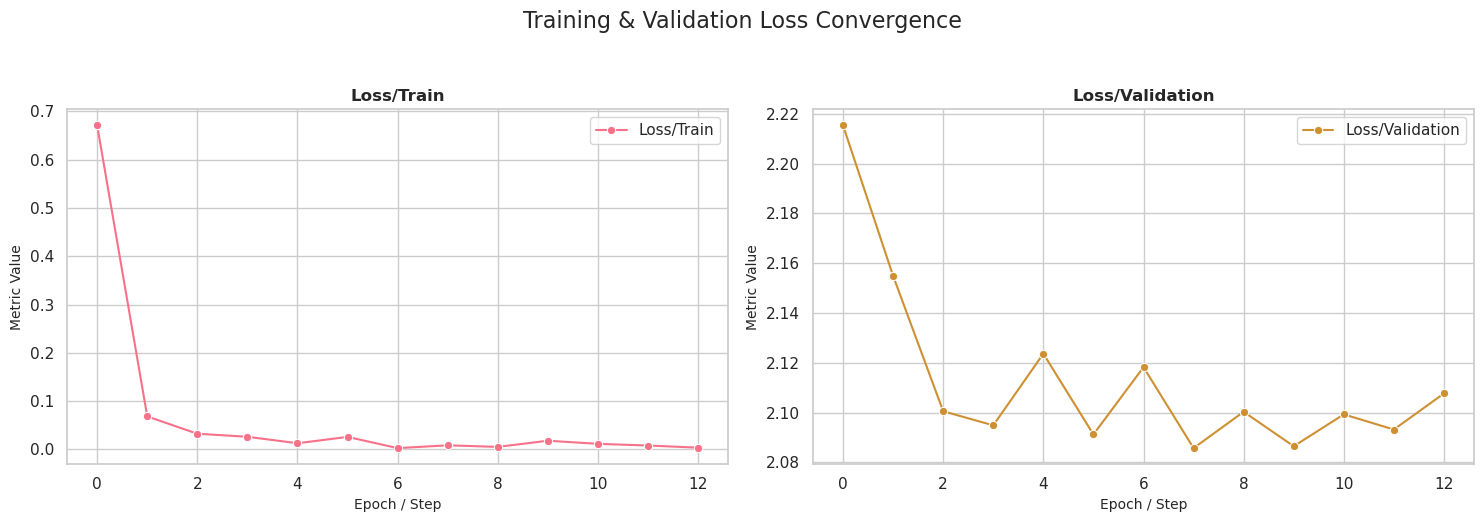

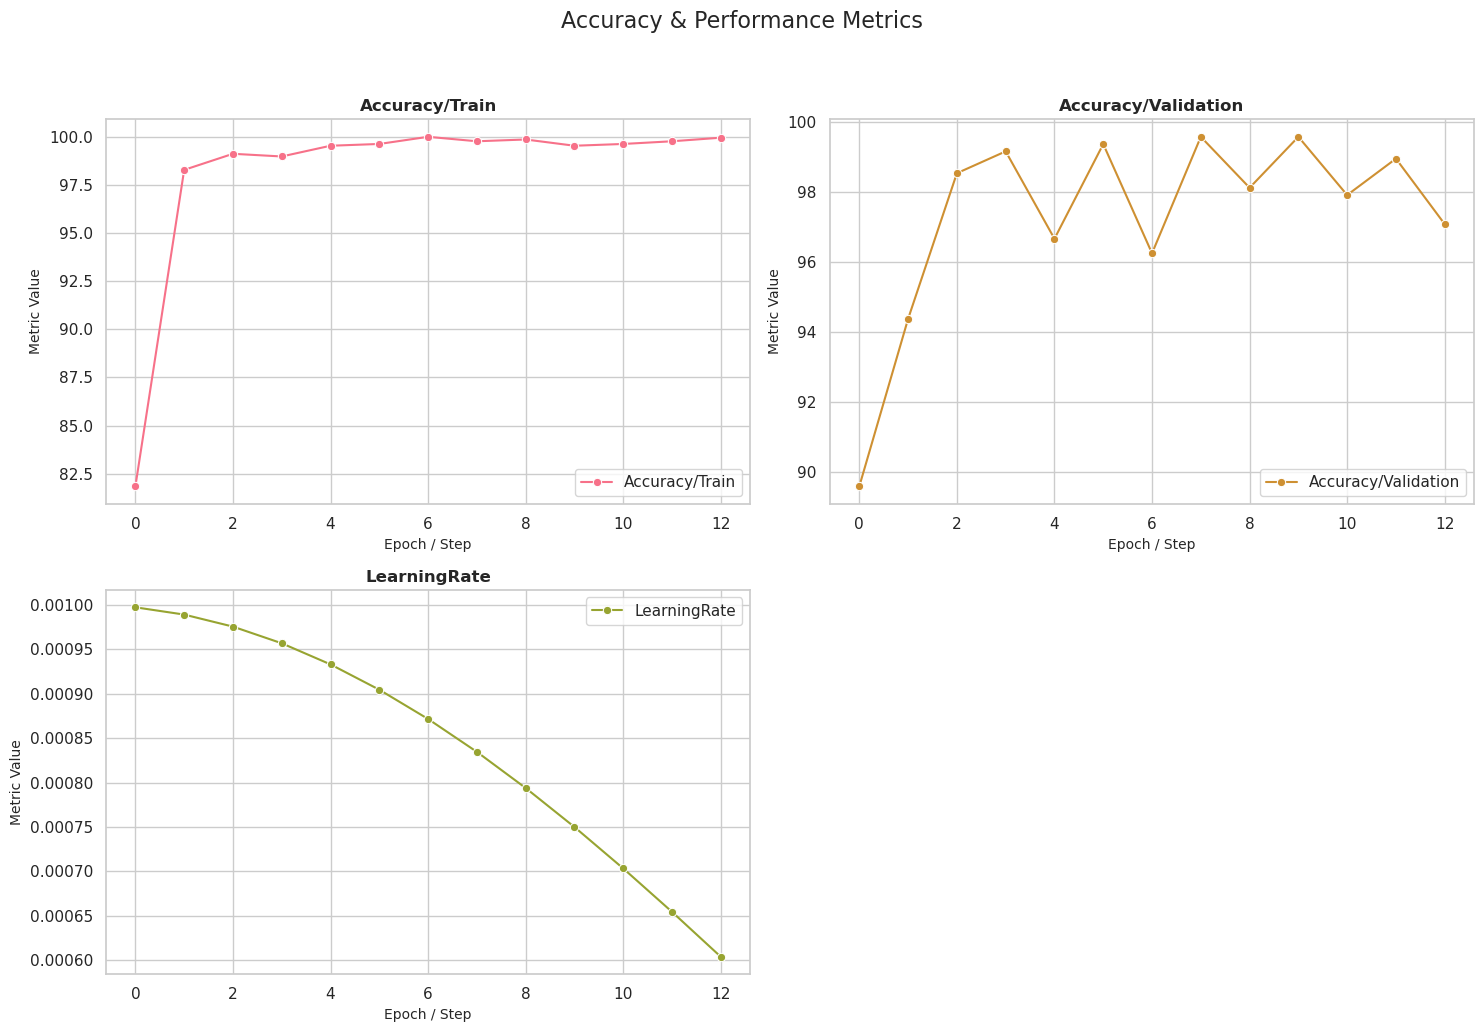

In [3]:
# Set standard visualization theme
sns.set_theme(style="whitegrid")

# Group metrics logically into Arrays based on naming convention
loss_metrics = [m for m in tags if "loss" in m.lower()]
perf_metrics = [m for m in tags if "loss" not in m.lower()]


def plot_metric_group(metric_names, group_title):
    if not metric_names:
        return

    num_metrics = len(metric_names)
    cols = 2
    rows = (num_metrics + 1) // cols
    if rows == 0:
        rows = 1

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if num_metrics > 1 else [axes]

    for idx, metric in enumerate(metric_names):
        subset = df[df["Metric"] == metric]

        sns.lineplot(
            data=subset,
            x="Step",
            y="Value",
            marker="o",
            ax=axes[idx],
            label=metric,
            color=sns.color_palette("husl", 8)[idx % 8],
        )

        axes[idx].set_title(f"{metric}", fontsize=12, fontweight="bold")
        axes[idx].set_xlabel("Epoch / Step", fontsize=10)
        axes[idx].set_ylabel("Metric Value", fontsize=10)
        axes[idx].legend()

    # Remove any empty subplots if metrics count is odd
    for i in range(num_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(group_title, fontsize=16, y=1.02 + (0.02 / rows))
    plt.tight_layout()
    plt.show()


# Render Plots
plot_metric_group(loss_metrics, "Training & Validation Loss Convergence")
plot_metric_group(perf_metrics, "Accuracy & Performance Metrics")

## 4. Deep Dive: Layer Analysis (Images & Histograms)

TensorBoard doesn't just track scalar metrics; it tracked all internal gradients and feature maps during your fine-tuning loop.

Here is a full breakdown of the internal parameters logged for this run:


In [ ]:
# Programmatically extract and display the internal logged matrices
print("--- Internal Model Diagnostics Logged ---\n")

print(f"📦 1. Convolutional Activations (Feature Maps):")
activations = [img for img in event_acc.Tags()["images"] if "Activations" in img]
for a in activations:
    print(f"   - {a}")

print(f"\n🧠 2. Weight Distributions (Kernels):")
histograms = event_acc.Tags()["histograms"]
weight_hists = [h for h in histograms if "Weights" in h]
print(
    f"   - Logged {len(weight_hists)} unique convolutional weight tensors. (e.g. {weight_hists[0]}, {weight_hists[-1]})"
)

print(f"\n📉 3. Gradient Flow Health:")
grad_hists = [h for h in histograms if "Gradients" in h]
print(
    f"   - Logged {len(grad_hists)} unique gradient flow arrays mapped exactly to the weight matrices."
)

print("\n💡 NOTE:")
print(
    "To interactively view these histograms and image grids (to see exactly what the model sees), run:"
)
print(f"   !tensorboard --logdir {os.path.dirname(log_path)}")

--- Internal Model Diagnostics Logged ---

📦 1. Convolutional Activations (Feature Maps):
   - Activations/Block_model.0.conv
   - Activations/Block_model.1.conv
   - Activations/Block_model.2.cv1.conv

🧠 2. Weight Distributions (Kernels):
   - Logged 39 unique convolutional weight tensors. (e.g. Weights/Histogram/model.0.conv, Weights/Histogram/model.10.conv.conv)

📉 3. Gradient Flow Health:
   - Logged 39 unique gradient flow arrays mapped exactly to the weight matrices.

💡 NOTE:
To interactively view these histograms and image grids (to see exactly what the model sees), run:
   !tensorboard --logdir runs/yolo26-aksara_20260420-170211
